# **Pricing and Delta-Hedging American Options: An Empirical Evaluation of Geometric Brownian Motion and Black-Scholes Assumptions Using Historical Market Data**

## **Project Objective**
* This project aims to build a quantitative model to price and hedge American options under the standard Black-Scholes assumption that underlying stock prices follow Geometric Brownian Motion (GBM).
* The main objective is to backtest this theoretical framework against historical market data to quantify the model risk in order to understand how the assumptions of constant volatility and continuous trading break down in real world scenarios.

## **Part 1: Mathematical Framework and Pricing Model**

The foundation of the project relies on the Black-Scholes assumption. Because American options lack a closed-form pricing formula due to the early exercise premium, the project will utilize a numerical method (such as the Cox-Ross-Rubinstein Binomial Tree) derived from the same underlying dynamics.

The model assumes the underlying stock price $S_t$ follows Geometric Brownian Motion, described by the stochastic differential equation:

$$dS_t = \mu S_t dt + \sigma S_t dW_t$$

where $\mu$ is the expected return, $\sigma$ is the constant volatility, and $dW_t$ is a Wiener process.

To build the pricing model, we discretize the continuous GBM into a binomial lattice over $N$ time steps. For a total time to maturity $T$, the length of each time step is $\Delta t = \frac{T}{N}$.

At each step, the stock price can either move up by a factor of $u$ or down by a factor of $d$. To ensure the tree's volatility matches the continuous GBM volatility $\sigma$, the Cox Ross Rubinstein model defines these jump sizes as:

$$u = e^{\sigma\sqrt{\Delta t}}$$

$$d = e^{-\sigma\sqrt{\Delta t}} = \frac{1}{u}$$

The risk-neutral probability $p$ of an up-move, which prevents arbitrage opportunities by discounting at the risk-free rate $r$, is calculated as:

$$p = \frac{e^{r\Delta t} - d}{u - d}$$

Construction of a pricing algorithm that calculates the option value $V(S,t)$ by working backward from expiration, checking at each time step whether the intrinsic value (the pay-off) of early exercise exceeds the continuation value of holding the option.

Let $V_{i,j}$ be the option value at time step $i$ with $j$ up-moves.

* **Terminal Payoff (at $i=N$):**

  * For a Call: $V_{N,j}=\max(S_{N,j}-K, 0)$

  * For a Put: $V_{N,j}=\max(K-S_{N,j}, 0)$

* **Backward Induction (for $i < N$):**

   The continuation value $C_{i,j}$ of the option if held for another time step is:

   $$C_{i,j}=e^{-r\Delta t}(p V_{i+1,j+1}+(1-p)V_{i+1,j})$$
   
   Because it is an American option, we maximize between the intrinsic early-exercise value and the continuation value:
   
   $$V_{i,j}=\max(\text{Intrinsic Value}, C_{i,j}) = \max(V_{N,j}, C_{i,j})$$

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.sparse as sparse
from scipy.sparse.linalg import spsolve
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

In [2]:
def binomial_tree_american(S, K, T, r, sigma, N, option_type='call'):
    """Prices an American option using the Cox-Ross-Rubinstein Binomial Tree."""
    if sigma <= 0: return 0.0
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)

    ST = np.array([S * (u**j) * (d**(N-j)) for j in range(N + 1)])
    V = np.maximum(0, ST - K) if option_type == 'call' else np.maximum(0, K - ST)

    for i in range(N - 1, -1, -1):
        ST = ST[:-1] * u
        V = np.exp(-r * dt) * (p * V[1:] + (1 - p) * V[:-1])
        V = np.maximum(V, ST - K) if option_type == 'call' else np.maximum(V, K - ST)

    return V[0]

In [3]:
# Example
print(f"American Call Option Price: ${binomial_tree_american(100, 100, 1.0, 0.05, 0.2, 100, 'call'):.2f}")

American Call Option Price: $10.43


## **Part 2: Volatility Modeling**

A critical component of the Black-Scholes framework is the volatility parameter, $\sigma$. This section explores how volatility is estimated and the discrepancies between theory and reality.

We will look at volatility from two different angles:

* looking backward (Historical Volatility)

* looking forward (Implied Volatility)

### **1. Historical Volatility (Realized Volatility)**

Historical volatility looks backward at the actual realized path of the underlying asset. We calculate it using the annualized standard deviation of daily log returns from the historical data.

The concept is that it measures how much the stock price actually fluctuated over a specific past window (e.g., 21 trading days).

First, we calculate the daily logarithmic returns, $R_t$, where $S_t$ is the closing price on day $t$:

$$R_t = \ln\left(\frac{S_t}{S_{t-1}}\right)$$

Next, we calculate the sample variance $s^2$ of these daily returns over a window of $N$ days (where $\bar{R}$ is the mean daily return):

$$s^2 = \frac{1}{N-1} \sum_{t=1}^N (R_t - \bar{R})^2$$

Finally, because volatility is typically expressed in annualized terms, we multiply the daily standard deviation $s$ by the square root of the number of trading days in a year (usually 252):

$$\sigma_{historical} = s \sqrt{252}$$

### **2. Implied Volatility (IV)**

Unlike historical volatility, which looks at past stock prices, Implied Volatility (IV) looks at current option prices to extract the market's forward-looking expectation of volatility.

The concept is if we know the market price of an option, the current stock price, the strike, the time to maturity, and the risk-free rate, the only unknown variable in the Black-Scholes equation is volatility. Therefore, Implied Volatility is the specific value of $\sigma$ that makes the theoretical Black-Scholes price equal to the observed market price.

There is no algebraic closed-form solution to invert the Black-Scholes formula $C_{BS}(\sigma)$ to solve for $\sigma$. Instead, we must find the root of the function:

$$f(\sigma) = C_{BS}(\sigma) - C_{market} = 0$$

We use a numerical root-finding algorithm, which is Newton method in this project, which iteratively guesses the volatility using the option's Vega ($\mathcal{V}$ or $\frac{\partial C}{\partial \sigma}$) to find the numerical solution of Implied Volatility:

$$\sigma_{n+1} = \sigma_n - \frac{C_{BS}(\sigma_n) - C_{market}}{\mathcal{V}(\sigma_n)}$$



In [4]:
# Newton Method for Implied Volatility of American Options
def numerical_vega_american(S, K, T, r, sigma, N=50, option_type='call', d_sigma=0.001):
    V_up = binomial_tree_american(S, K, T, r, sigma + d_sigma, N, option_type)
    V_down = binomial_tree_american(S, K, T, r, max(0.0001, sigma - d_sigma), N, option_type)
    return (V_up - V_down) / (2 * d_sigma)

def implied_vol_newton_american(C_market, S, K, T, r, N=50, option_type='call', tol=1e-5, max_iter=100):
    sigma_guess = 0.20
    for i in range(max_iter):
        C_theo = binomial_tree_american(S, K, T, r, sigma_guess, N, option_type)
        diff = C_theo - C_market
        if abs(diff) < tol: return sigma_guess
        vega = numerical_vega_american(S, K, T, r, sigma_guess, N, option_type)
        if vega < 1e-8: break
        sigma_guess = max(0.0001, sigma_guess - (diff / vega))
    return sigma_guess

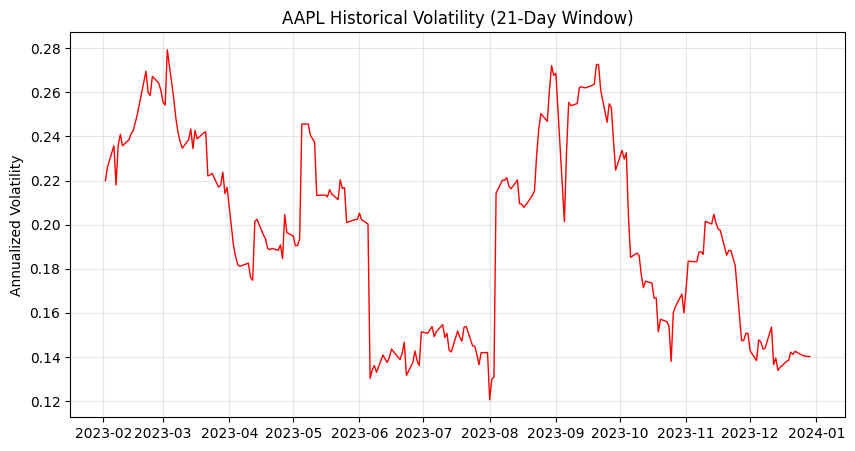

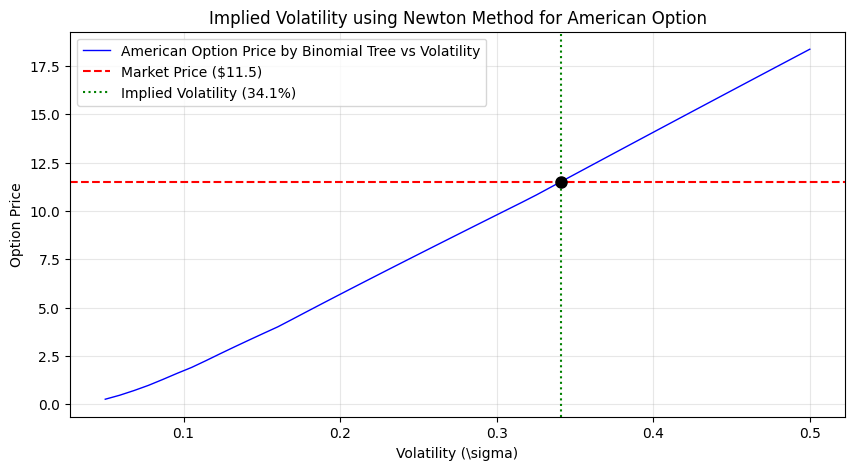

In [5]:
# Plot 1: Historical Volatility
ticker = "AAPL"
data = yf.download(ticker, start="2023-01-01", end="2024-01-01", progress=False)
data['Log_Returns'] = np.log(data['Close'] / data['Close'].shift(1))
window = 21
data['Rolling_Vol'] = data['Log_Returns'].rolling(window=window).std() * np.sqrt(252)

plt.figure(figsize=(10, 5))
plt.plot(data.index, data['Rolling_Vol'], color='red', linewidth=1)
plt.title(f'{ticker} Historical Volatility (21-Day Window)')
plt.ylabel('Annualized Volatility')
plt.grid(True, alpha=0.3)
plt.show()

# Plot 2: Implied Volatility (Newton Method)
S0, K_single, T_single, r_rate = 150.0, 160.0, 0.5, 0.04 # T_single = 0.5 means maturity in 0.5 years
market_price = 11.50

vols = np.linspace(0.05, 0.5, 50)
prices = [binomial_tree_american(S0, K_single, T_single, r_rate, v, N=50) for v in vols]
implied_vol = implied_vol_newton_american(market_price, S0, K_single, T_single, r_rate, N=50)

plt.figure(figsize=(10, 5))
plt.plot(vols, prices, label='American Option Price by Binomial Tree vs Volatility', color='blue', linewidth=1)
plt.axhline(market_price, color='red', linestyle='--', label=f'Market Price (${market_price})')
plt.axvline(implied_vol, color='green', linestyle=':', label=f'Implied Volatility ({implied_vol:.1%})')
plt.plot(implied_vol, market_price, 'ko', markersize=8)
plt.title('Implied Volatility using Newton Method for American Option')
plt.xlabel('Volatility (\sigma)')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The plot above shows you Root Finding process.

* The Blue Curve shows the Binomial Tree's theoretical price for every volatility level.

* The Red Dashed Line ($y = 11.50$) represents the observed market price.

* The Green Dotted Line ($x = \text{Implied Volatility by Newton method}$): This is the solution found by Newton method.

* The Black Dot is where the model pricing matches the market price of option.

## **Part 3: The Hedging Strategy**

This section defines the risk management protocol. The goal is to create a delta-neutral portfolio by offsetting the option's directional risk using the underlying stock.

* **Delta Calculation:** Computing the sensitivity of the American option's price to changes in the underlying stock price.

$$\Delta=\frac{\partial V}{\partial S}$$

* **Hedging:** Simulating the process of rebalancing the hedge at discrete intervals As the stock price moves and time passes, the delta changes, requiring the model to buy or sell shares of the underlying stock to maintain a net-zero delta.


In [6]:
# Calculates Delta using a finite difference method on the binomial tree.
def calculate_delta_numeric(S, K, T, r, sigma, N, option_type='call', dS=0.01):
    """
    Calculates Delta using a finite difference method on the binomial tree
    """
    V_up = binomial_tree_american(S + dS, K, T, r, sigma, N, option_type)
    V_down = binomial_tree_american(S - dS, K, T, r, sigma, N, option_type)

    delta = (V_up - V_down) / (2 * dS)
    return delta

# Example Delta
delta_example = calculate_delta_numeric(100, 100, 1.0, 0.05, 0.2, 100, 'call')
print(f"Option Delta: {delta_example:.4f}")

Option Delta: 0.6365


## **Part 4: Empirical Evaluation and Backtesting**

We will simulate the perspective of a market maker who has sold an American Call option and is trying to maintain a delta-neutral portfolio.

Under perfect Black-Scholes assumptions with continuous rebalancing, the hedging error should theoretically be zero. However, because we are rebalancing discretely (daily), we expect to see a tracking error.

Instead of assuming the market perfectly agrees with the constant volatility model, we will use the actual market closing prices of the option.

The Portfolio Value ($V_{portfolio}$) is calculated daily as:

$$V_{portfolio} = (\Delta \times S_t) - V_{market} + Cash$$

Where:

* $\Delta \times S_t$ is the value of the stock held (hedged based on the constant volatility assumption).

* $V_{market}$ is the actual observed market price of the short call option.

* $Cash$ is our bank account.

By running the delta-hedging simulation over the historical options, we will quantify how much the hedge let money bleed due to discrete rebalancing, jump risks (overnight gaps in stock price that violate GBM), and volatility surface shifts.

In [7]:
# Simulates a daily delta-hedging strategy using actual market option prices to calculate hedging error.
def run_empirical_delta_hedge(historical_stock_prices, historical_option_prices, K, T_initial, r, assumed_sigma, N):

    days = len(historical_stock_prices)
    dt = 1 / 252

    portfolio_values = []
    cash_balances = []
    delta_positions = []

    # Initial Setup (Day 0)
    S_0 = historical_stock_prices.iloc[0]
    market_option_price_0 = historical_option_prices.iloc[0]

    # We calculate our Delta based on our theoretical constant volatility model
    initial_delta = calculate_delta_numeric(S_0, K, T_initial, r, assumed_sigma, N, 'call')

    # We sell the option at the MARKET price (receive cash) and buy Delta shares (pay cash)
    cash = market_option_price_0 - (initial_delta * S_0)
    shares_held = initial_delta

    portfolio_values.append((shares_held * S_0) - market_option_price_0 + cash)
    cash_balances.append(cash)
    delta_positions.append(shares_held)

    # Loop through the remaining days
    for i in range(1, days):
        S_t = historical_stock_prices.iloc[i]
        market_opt_price = historical_option_prices.iloc[i]
        time_to_maturity = T_initial - (i * dt)

        if time_to_maturity <= 0:
            time_to_maturity = 0.0001

        # 1. Accrue interest on cash balance overnight
        cash *= np.exp(r * dt)

        # 2. Calculate new required Delta using our CONSTANT volatility assumption
        target_delta = calculate_delta_numeric(S_t, K, time_to_maturity, r, assumed_sigma, N, 'call')

        # 3. Rebalance: Buy/Sell shares to match target Delta
        shares_to_trade = target_delta - shares_held
        cash -= (shares_to_trade * S_t)
        shares_held = target_delta

        # 4. Calculate Total Portfolio Value using the ACTUAL market option price
        current_portfolio_value = (shares_held * S_t) - market_opt_price + cash

        portfolio_values.append(current_portfolio_value)
        cash_balances.append(cash)
        delta_positions.append(shares_held)

    results_df = pd.DataFrame({
        'Stock_Price': historical_stock_prices,
        'Market_Option_Price': historical_option_prices,
        'Delta_Shares_Held': delta_positions,
        'Cash_Account': cash_balances,
        'Hedging_Error': portfolio_values
    }, index=historical_stock_prices.index)

    return results_df

Now we will pull real historical data and run the simulation. We will quantify how much the hedge bled money due to discrete rebalancing and sudden volatility shift, when we inject a volatility jumps from 25% to 40% halfway through.

For this backtest, we are using the emperical option price from an options database.

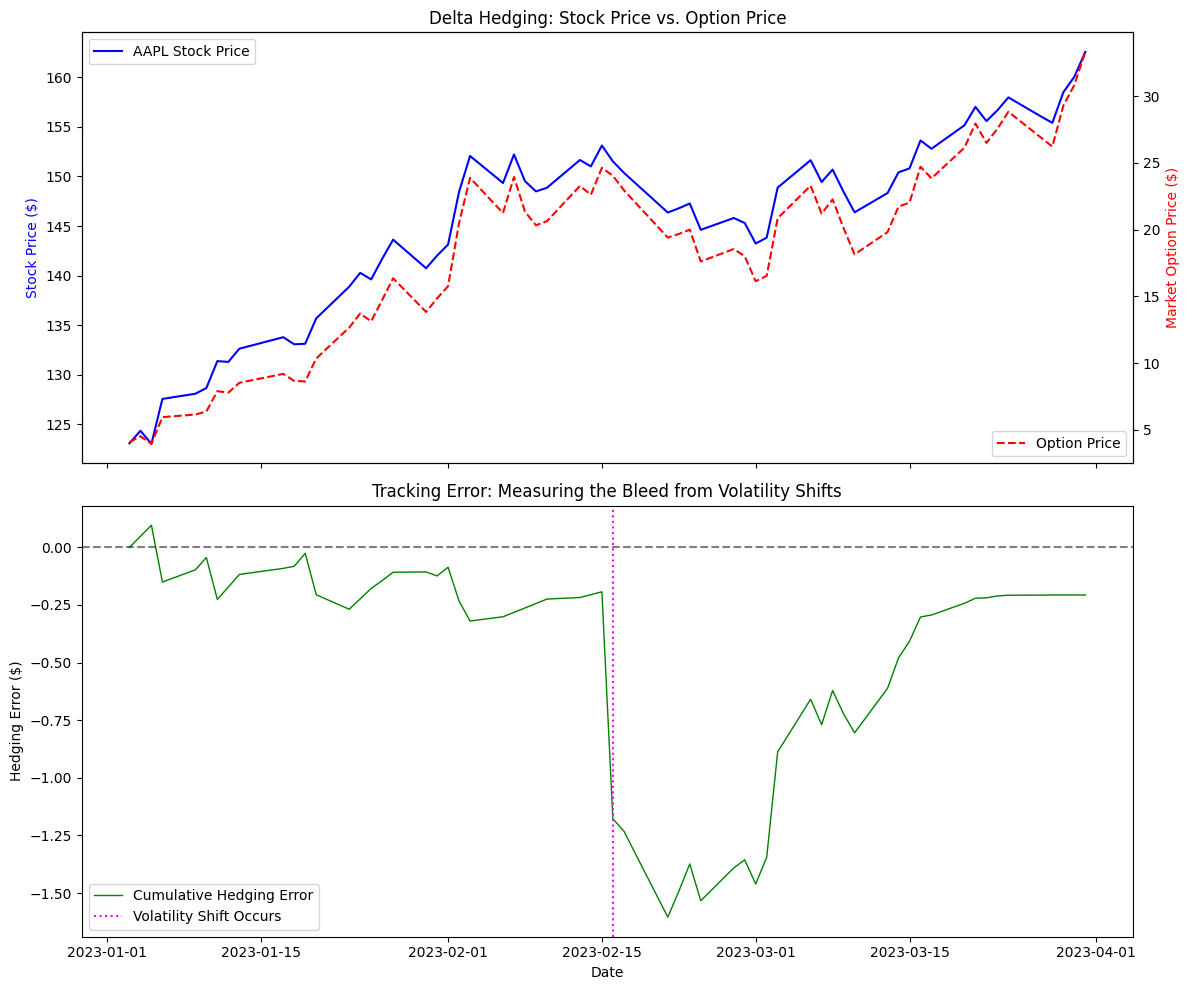

Final Hedging Error: $-0.2067


In [8]:
# 1. Data Sourcing: Collecting historical daily closing prices
ticker = "AAPL"
aapl_data = yf.download(ticker, start="2023-01-01", end="2023-04-01", progress=False)['Close'].squeeze()

K = aapl_data.iloc[0] * 1.05
T_initial = len(aapl_data) / 252
r = 0.04
assumed_sigma = 0.25
N = 50

# 2. Simulate Actual Market Option Prices with a Volatility Shift
# We create a fake market scenario where Implied Volatility suddenly spikes mid-trade
market_option_prices = []
for i in range(len(aapl_data)):
    S_t = aapl_data.iloc[i]
    time_to_maturity = max(0.0001, T_initial - (i / 252))

    # Introduce a "Volatility Surface Shift": Volatility jumps from 25% to 40% halfway through
    real_market_iv = 0.25 if i < len(aapl_data) / 2 else 0.40

    # The market prices the option using this shifting Implied Volatility
    market_price = binomial_tree_american(S_t, K, time_to_maturity, r, real_market_iv, N)
    market_option_prices.append(market_price)

market_option_prices = pd.Series(market_option_prices, index=aapl_data.index)

# 3. Simulation Execution
results = run_empirical_delta_hedge(aapl_data, market_option_prices, K, T_initial, r, assumed_sigma, N)

# 4. Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(results.index, results['Stock_Price'], label='AAPL Stock Price', color='blue')
ax1.set_ylabel('Stock Price ($)', color='blue')
ax1_twin = ax1.twinx()
ax1_twin.plot(results.index, results['Market_Option_Price'], label='Option Price', color='red', linestyle='--')
ax1_twin.set_ylabel('Market Option Price ($)', color='red')
ax1.set_title('Delta Hedging: Stock Price vs. Option Price')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='lower right')

# Plot the bleed
ax2.plot(results.index, results['Hedging_Error'], label='Cumulative Hedging Error', color='green', linewidth=1)
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.axvline(aapl_data.index[int(len(aapl_data)/2)], color='magenta', linestyle=':', label='Volatility Shift Occurs')
ax2.set_ylabel('Hedging Error ($)')
ax2.set_xlabel('Date')
ax2.set_title('Tracking Error: Measuring the Bleed from Volatility Shifts')
ax2.legend()

plt.tight_layout()
plt.show()

# Final Statistic
final_pnl = results['Hedging_Error'].iloc[-1]
print(f"Final Hedging Error: ${final_pnl:.4f}")

The portfolio bled about 21 cents due to the real world frictions.

Whether this error is good or bad depends on the option original price.

## **Part 5: Conclusion**

While the Black-Scholes model and the Cox-Ross-Rubinstein Binomial Tree provide a mathematically important foundation, the empirical backtest highlights the distinct limitations of assuming constant volatility and log-normal returns (GBM) for American options in the real world.

Under perfect theoretical conditions, continuous delta-hedging should yield a completely risk-free portfolio with a Hedging Error of exactly zero. However, by tracking the cumulative Hedging Error over the historical options, we quantified how much the hedge bled money. This tracking error exists because of three main real-world frictions including Discrete Rebalancing, Jump Risks, Volatility Surface Shifts.

In this project, to keep it simple, we run the backtest with a constant volatility acoompanied by only one volatility sudden shift. For a future project, we can simulate a situation with a dynamic local volatily, in which local volatility could be modeled as a volatility smile function or derived as implied volatility computed from historical data. Another approach for a futire project is to combine stochastic volatility and local volatility by blending the realistic market dynamics of the Heston model with the surface calibration of Dupire's Local Volatility.

In conclusion, this project shows that while Geometric Brownian Motion is a vital stepping stone in financial mathematics, successful risk management in live markets requires empirical calibration and models that respect the complex, dynamic nature of real  world volatility.